# Step 6 - Why Better Tracks Matter: Route Analytics

Once reconstruction works, we use the resulting trajectories for downstream analytics:

1. **Route distance** - how far did the aircraft actually fly?
2. **Deviation from expected path** - how far off the great-circle was the real route?
3. **CO2 emissions proxy** - how much fuel was burned?

The key insight: if you use only raw ADS-B (which has a gap over the ocean), you **underestimate** the true route distance. Better reconstruction gives more accurate downstream analytics.

**Run order:** Cell 1 -> 2 -> 3 -> 4 -> 5 -> 6

## Cell 1 - Setup

In [ ]:
import sys, os, json as _json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyproj import Geod
from scipy.interpolate import interp1d
from tqdm import tqdm

NB_DIR   = Path(r'C:\Users\marko\Desktop\AeroML3(og)\AeroML3\notebook')
NOEL_DIR = Path(r'C:\Users\marko\Desktop\AeroML3(og)\AeroML3\noel_part')
if not NOEL_DIR.exists():
    for _c in [Path('../noel_part'), Path('../../noel_part')]:
        if _c.resolve().exists(): NOEL_DIR = _c.resolve(); break

sys.path.insert(0, str(NB_DIR))
sys.path.insert(0, str(NOEL_DIR))
os.chdir(NOEL_DIR)

CLEAN_DIR = NOEL_DIR / 'cleaned_data_final'
OUT_DIR   = NOEL_DIR.parent / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

NORM_PATH = NB_DIR.parent / 'artifacts' / 'step4_ml_dataset' / 'dataset' / 'normalization_stats.json'
MODEL_V2  = NB_DIR.parent / 'step5_v2' / 'best_model_v2.pt'
MODEL_PATH = MODEL_V2

from step3_baseline import reconstruct_gap_baseline
from step5_kalman_aeroml3 import reconstruct_single_kalman
from step5_train_gru_v2 import TrajectoryGRU, gc_interpolate_batch

geod   = Geod(ellps='WGS84')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(NORM_PATH) as f:
    stats = _json.load(f)
BEFORE_STEPS = stats['before_steps']
AFTER_STEPS  = stats['after_steps']
RESAMPLE_SEC = stats['resample_sec']

model_gru = TrajectoryGRU().to(device)
model_gru.load_state_dict(torch.load(str(MODEL_PATH), map_location=device))
model_gru.eval()

# -- GRU helpers (normalization + inference) --
def _normalize_seq(df):
    lat = (df['latitude'].values  - stats['lat']['mean']) / stats['lat']['std']
    lon = (df['longitude'].values - stats['lon']['mean']) / stats['lon']['std']
    vel = (df['velocity_mps'].values - stats['vel']['mean']) / stats['vel']['std']
    hdg = np.radians(df['heading_deg'].values)
    alt = (df['altitude'].values  - stats['alt']['mean']) / stats['alt']['std']
    return np.stack([lat, lon, vel, np.sin(hdg), np.cos(hdg), alt], axis=1).astype(np.float32)

def _resample_df(df, freq_sec):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = (df.dropna(subset=['latitude','longitude','altitude','velocity_mps','heading_deg'])
            .sort_values('timestamp').drop_duplicates('timestamp').set_index('timestamp'))
    cols = ['latitude','longitude','altitude','velocity_mps','heading_deg']
    grid = pd.date_range(df.index[0], df.index[-1], freq=f'{freq_sec}s')
    out  = df[cols].reindex(df[cols].index.union(grid)).interpolate('time').loc[grid]
    return out.reset_index().rename(columns={'index':'timestamp'})

def _prepare_seq(df, n_steps, from_end):
    arr = _normalize_seq(df)
    arr = arr[-n_steps:] if from_end else arr[:n_steps]
    n_valid = arr.shape[0]
    pad = np.zeros((n_steps - n_valid, arr.shape[1]), dtype=np.float32)
    if from_end:
        arr  = np.vstack([pad, arr])
        mask = np.array([0.0]*(n_steps - n_valid) + [1.0]*n_valid, dtype=np.float32)
    else:
        arr  = np.vstack([arr, pad])
        mask = np.array([1.0]*n_valid + [0.0]*(n_steps - n_valid), dtype=np.float32)
    return arr, mask

def run_gru(bef_df, aft_df, dt=60.0):
    required = ['latitude','longitude','altitude','velocity_mps','heading_deg']
    if any(c not in bef_df.columns or not np.isfinite(bef_df[c].values).any() for c in required):
        return None
    bef_rs = _resample_df(bef_df, RESAMPLE_SEC)
    aft_rs = _resample_df(aft_df, RESAMPLE_SEC)
    if len(bef_rs) == 0 or len(aft_rs) == 0: return None
    bef_arr, bef_mask = _prepare_seq(bef_rs, BEFORE_STEPS, from_end=True)
    aft_arr, aft_mask = _prepare_seq(aft_rs, AFTER_STEPS,  from_end=False)
    t0 = bef_df['timestamp'].iloc[-1]
    t1 = aft_df['timestamp'].iloc[0]
    gap_s = (t1 - t0).total_seconds()
    n_out = max(1, int(round(gap_s / dt)))
    taus  = np.array([(i+1)/(n_out+1) for i in range(n_out)], dtype=np.float32)
    la0 = np.array([float(bef_df['latitude'].iloc[-1])],  dtype=np.float32)
    lo0 = np.array([float(bef_df['longitude'].iloc[-1])], dtype=np.float32)
    la1 = np.array([float(aft_df['latitude'].iloc[0])],   dtype=np.float32)
    lo1 = np.array([float(aft_df['longitude'].iloc[0])],  dtype=np.float32)
    bl_lat, bl_lon = gc_interpolate_batch(la0, lo0, la1, lo1, taus[None, :])
    def _t(a): return torch.FloatTensor(a[None]).to(device)
    batch = {'before_seq': _t(bef_arr), 'before_mask': _t(bef_mask),
             'after_seq':  _t(aft_arr), 'after_mask':  _t(aft_mask),
             'gap_norm':     torch.FloatTensor([gap_s/6000.0]).to(device),
             'adsc_tau':     torch.FloatTensor(taus[None]).to(device),
             'baseline_lat': torch.FloatTensor(bl_lat.astype(np.float32)).to(device),
             'baseline_lon': torch.FloatTensor(bl_lon.astype(np.float32)).to(device)}
    with torch.no_grad():
        pred_lat, pred_lon = model_gru(batch)
    pred_lat = pred_lat.cpu().numpy()[0]
    pred_lon = pred_lon.cpu().numpy()[0]
    alt0 = float(bef_df['altitude'].iloc[-1])
    alt1 = float(aft_df['altitude'].iloc[0])
    return pd.DataFrame({'latitude': pred_lat, 'longitude': pred_lon,
                         'altitude': np.linspace(alt0, alt1, n_out),
                         'timestamp': [t0 + pd.Timedelta(seconds=dt*(i+1)) for i in range(n_out)]})

CO2_KG_PER_KM = 19.0  # widebody average: ~6 kg fuel/km x 3.16 CO2 factor

flights = [f for s in sorted(CLEAN_DIR.iterdir()) if s.is_dir()
           for f in sorted(s.iterdir()) if f.is_dir()]
print(f'Working dir   : {os.getcwd()}')
print(f'Device        : {device}')
print(f'Total flights : {len(flights)}')
print(f'GRU model     : {MODEL_PATH.name}')
print(f'CO2 proxy     : {CO2_KG_PER_KM} kg CO2/km (widebody average)')


## Cell 2 - Helper functions

In [9]:
def reconstruct_forward_only(before_df, after_df, dt=60.0):
    last_time  = before_df['timestamp'].iloc[-1]
    first_time = after_df['timestamp'].iloc[0]
    n_steps = max(1, int(round((first_time - last_time).total_seconds() / dt)))
    lat0 = float(before_df['latitude'].iloc[-1]);  lon0 = float(before_df['longitude'].iloc[-1])
    alt0 = float(before_df['altitude'].iloc[-1])
    lat1 = float(after_df['latitude'].iloc[0]);    lon1 = float(after_df['longitude'].iloc[0])
    alt1 = float(after_df['altitude'].iloc[0])
    pts  = geod.npts(lon0, lat0, lon1, lat1, n_steps)
    lats = np.array([p[1] for p in pts]); lons = np.array([p[0] for p in pts])
    alts = np.linspace(alt0, alt1, n_steps)
    timestamps = [last_time + pd.Timedelta(seconds=dt*(i+1)) for i in range(n_steps)]
    return pd.DataFrame({'latitude': lats, 'longitude': lons,
                         'altitude': alts, 'timestamp': timestamps, 'interpolated': True})

def path_length_km(df, lat_col='latitude', lon_col='longitude'):
    lats = df[lat_col].values; lons = df[lon_col].values
    ok = np.isfinite(lats) & np.isfinite(lons)
    lats = lats[ok]; lons = lons[ok]
    if len(lats) < 2: return 0.0
    _, _, dists = geod.inv(lons[:-1], lats[:-1], lons[1:], lats[1:])
    return float(np.nansum(np.abs(dists))) / 1000.0

def max_deviation_km(recon_df, start_lat, start_lon, end_lat, end_lon):
    if len(recon_df) == 0: return 0.0
    R = 6_371_000.0
    slat, slon = np.radians(start_lat), np.radians(start_lon)
    elat, elon = np.radians(end_lat),   np.radians(end_lon)
    brg_ref = np.arctan2(
        np.sin(elon - slon) * np.cos(elat),
        np.cos(slat)*np.sin(elat) - np.sin(slat)*np.cos(elat)*np.cos(elon - slon)
    )
    deviations = []
    for _, row in recon_df.iterrows():
        la2 = np.radians(row['latitude']); lo2 = np.radians(row['longitude'])
        dlat = la2 - slat; dlon = lo2 - slon
        a   = np.sin(dlat/2)**2 + np.cos(slat)*np.cos(la2)*np.sin(dlon/2)**2
        d13 = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
        brg13 = np.arctan2(np.sin(dlon)*np.cos(la2),
                           np.cos(slat)*np.sin(la2) - np.sin(slat)*np.cos(la2)*np.cos(dlon))
        xte = np.arcsin(np.clip(np.sin(d13)*np.sin(brg13 - brg_ref), -1, 1)) * R
        deviations.append(abs(xte))
    return float(np.max(deviations)) / 1000.0 if deviations else 0.0

print('Helper functions defined.')


Helper functions defined.


## Cell 3 - Compute analytics for all flights

In [ ]:
records = []
skipped = 0
DT = 60.0  # 60-second step for route analytics

print(f'Computing route analytics for {len(flights)} flights ...')

for flight_dir in tqdm(flights, desc='Analytics'):
    try:
        _bp  = next((flight_dir/p for p in ['adsb_before_clean.parquet','adsb_before.parquet']
                     if (flight_dir/p).exists()), None)
        _afp = next((flight_dir/p for p in ['adsb_after_clean.parquet','adsb_after.parquet']
                     if (flight_dir/p).exists()), None)
        _ap  = next((flight_dir/p for p in ['adsc_clean.parquet','adsc.parquet']
                     if (flight_dir/p).exists()), None)

        if not (_bp and _afp): skipped += 1; continue

        bef = pd.read_parquet(str(_bp)).dropna(subset=['latitude','longitude'])
        aft = pd.read_parquet(str(_afp)).dropna(subset=['latitude','longitude'])

        for df in [bef, aft]:
            df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
            df.sort_values('timestamp', inplace=True)
            df.reset_index(drop=True, inplace=True)

        if len(bef) < 4 or len(aft) < 4: skipped += 1; continue

        t_gap_start = bef['timestamp'].iloc[-1]
        t_gap_end   = aft['timestamp'].iloc[0]
        gap_min = (t_gap_end - t_gap_start).total_seconds() / 60
        if gap_min < 5: skipped += 1; continue

        bef_trim = bef.tail(90).reset_index(drop=True)
        aft_trim = aft.head(90).reset_index(drop=True)
        if len(bef_trim) < 2 or len(aft_trim) < 2: skipped += 1; continue

        start_lat = float(bef_trim['latitude'].iloc[-1])
        start_lon = float(bef_trim['longitude'].iloc[-1])
        end_lat   = float(aft_trim['latitude'].iloc[0])
        end_lon   = float(aft_trim['longitude'].iloc[0])

        # 1. Raw ADS-B distance -- only the actual coverage, gap is missing entirely
        raw_dist_km = path_length_km(bef) + path_length_km(aft)

        # 2. Great-circle gap distance (reference)
        _, _, gc_gap_m = geod.inv(start_lon, start_lat, end_lon, end_lat)
        gc_gap_km = abs(gc_gap_m) / 1000.0

        # 3. Reconstruct gap: Baseline + Kalman + GRU
        recon_base   = reconstruct_gap_baseline(bef_trim, aft_trim, dt=DT)
        recon_kalman = reconstruct_single_kalman(bef, aft_trim, dt=DT)
        recon_gru    = run_gru(bef_trim, aft_trim, dt=DT)

        # 4. Full route distance (ADS-B before + gap recon + ADS-B after)
        def full_route_km(gap_recon):
            full = pd.concat([bef[['latitude','longitude']],
                              gap_recon[['latitude','longitude']],
                              aft[['latitude','longitude']]], ignore_index=True)
            return path_length_km(full)

        base_dist_km   = full_route_km(recon_base)
        kalman_dist_km = full_route_km(recon_kalman)
        gru_dist_km    = full_route_km(recon_gru) if recon_gru is not None else np.nan

        # 5. ADS-C ground-truth route distance (if available)
        adsc_dist_km = np.nan
        if _ap:
            adsc = pd.read_parquet(str(_ap)).dropna(subset=['latitude','longitude'])
            adsc['timestamp'] = pd.to_datetime(adsc['timestamp'], utc=True).dt.tz_localize(None)
            adsc_gap = adsc[(adsc['timestamp'] > t_gap_start) &
                            (adsc['timestamp'] < t_gap_end)].reset_index(drop=True)
            if len(adsc_gap) >= 2:
                adsc_full = pd.concat([bef[['latitude','longitude']],
                                       adsc_gap[['latitude','longitude']],
                                       aft[['latitude','longitude']]], ignore_index=True)
                adsc_dist_km = path_length_km(adsc_full)

        # 6. Max lateral deviation from great-circle path
        base_dev_km   = max_deviation_km(recon_base,   start_lat, start_lon, end_lat, end_lon)
        kalman_dev_km = max_deviation_km(recon_kalman, start_lat, start_lon, end_lat, end_lon)
        gru_dev_km    = max_deviation_km(recon_gru, start_lat, start_lon, end_lat, end_lon) if recon_gru is not None else np.nan

        records.append({
            'flight':            flight_dir.name,
            'step':              flight_dir.parent.name,
            'gap_minutes':       round(gap_min, 1),
            'gc_gap_km':         round(gc_gap_km, 1),
            'raw_adsb_dist_km':  round(raw_dist_km,    1),
            'baseline_dist_km':  round(base_dist_km,   1),
            'kalman_dist_km':    round(kalman_dist_km, 1),
            'gru_dist_km':       round(gru_dist_km,    1) if not np.isnan(gru_dist_km) else np.nan,
            'adsc_true_dist_km': round(adsc_dist_km,   1) if not np.isnan(adsc_dist_km) else np.nan,
            'baseline_gap_km':   round(path_length_km(recon_base),   1),
            'kalman_gap_km':     round(path_length_km(recon_kalman), 1),
            'gru_gap_km':        round(path_length_km(recon_gru),    1) if recon_gru is not None else np.nan,
            'baseline_dev_km':   round(base_dev_km,   1),
            'kalman_dev_km':     round(kalman_dev_km, 1),
            'gru_dev_km':        round(gru_dev_km,    1) if not np.isnan(gru_dev_km) else np.nan,
            'raw_co2_kg':        round(raw_dist_km    * CO2_KG_PER_KM, 0),
            'baseline_co2_kg':   round(base_dist_km   * CO2_KG_PER_KM, 0),
            'kalman_co2_kg':     round(kalman_dist_km * CO2_KG_PER_KM, 0),
            'gru_co2_kg':        round(gru_dist_km    * CO2_KG_PER_KM, 0) if not np.isnan(gru_dist_km) else np.nan,
            'adsc_co2_kg':       round(adsc_dist_km   * CO2_KG_PER_KM, 0) if not np.isnan(adsc_dist_km) else np.nan,
        })

    except Exception: skipped += 1; continue

analytics_df = pd.DataFrame(records)
out_path = OUT_DIR / 'analytics_results.csv'
analytics_df.to_csv(out_path, index=False)
print(f'Flights analysed : {len(analytics_df)}')
print(f'Flights skipped  : {skipped}')
print(f'Saved -> {out_path}')


## Cell 4 - Route distance summary

Shows how much distance is **missed** by raw ADS-B vs each reconstruction method.

In [12]:
print("=" * 65)
print("ROUTE ANALYTICS -- Why Better Reconstruction Matters")
print("=" * 65)

print(f"\nFlights analysed : {len(analytics_df)}")
print(f"Avg gap duration : {analytics_df['gap_minutes'].mean():.1f} min")
print(f"Avg gap distance : {analytics_df['gc_gap_km'].mean():.0f} km (great-circle)")

# -- Route Distance -----------------------------------------------------------
print("\n-- Route Distance (full flight: ADS-B before + gap recon + ADS-B after) --")
print(f"{'Method':<22}  {'Mean dist (km)':>14}  {'vs Raw ADS-B':>13}  {'vs ADS-C truth':>15}")
print("-" * 70)

raw_mean  = analytics_df['raw_adsb_dist_km'].mean()
adsc_mean = analytics_df['adsc_true_dist_km'].dropna().mean()

for method, col in [
    ("Raw ADS-B (gap)",  "raw_adsb_dist_km"),
    ("Baseline",         "baseline_dist_km"),
    ("Kalman",           "kalman_dist_km"),
    ("GRU",              "gru_dist_km"),
    ("ADS-C truth",      "adsc_true_dist_km"),
]:
    vals = analytics_df[col].dropna()
    if len(vals) == 0: continue
    mean_val = vals.mean()
    vs_raw  = f"{mean_val - raw_mean:+.0f} km"  if method != "Raw ADS-B (gap)" else "--"
    vs_adsc = f"{mean_val - adsc_mean:+.0f} km" if (not np.isnan(adsc_mean) and method not in ["Raw ADS-B (gap)", "ADS-C truth"]) else "--"
    print(f"  {method:<20}  {mean_val:>14.0f}  {vs_raw:>13}  {vs_adsc:>15}")

# -- CO2 Proxy ----------------------------------------------------------------
print("\n-- CO2 Emissions Proxy (19 kg CO2/km, widebody average) --")
print(f"{'Method':<22}  {'Mean CO2 (kg)':>13}  {'Extra CO2 vs Raw':>18}")
print("-" * 58)
raw_co2 = analytics_df['raw_co2_kg'].mean()
for method, col in [
    ("Raw ADS-B (gap)",  "raw_co2_kg"),
    ("Baseline",         "baseline_co2_kg"),
    ("Kalman",           "kalman_co2_kg"),
    ("GRU",              "gru_co2_kg"),
    ("ADS-C truth",      "adsc_co2_kg"),
]:
    vals = analytics_df[col].dropna()
    if len(vals) == 0: continue
    mean_val = vals.mean()
    extra    = f"{mean_val - raw_co2:+.0f} kg" if method != "Raw ADS-B (gap)" else "--"
    print(f"  {method:<20}  {mean_val:>13.0f}  {extra:>18}")

# -- Max Deviation ------------------------------------------------------------
print("\n-- Max Lateral Deviation from Great-Circle Path --")
print(f"{'Method':<12}  {'Mean max deviation (km)':>24}")
print("-" * 40)
for method, col in [("Baseline", "baseline_dev_km"), ("Kalman", "kalman_dev_km"), ("GRU", "gru_dev_km")]:
    vals = analytics_df[col].dropna()
    if len(vals) == 0: continue
    print(f"  {method:<10}  {vals.mean():>24.1f}")

ROUTE ANALYTICS -- Why Better Reconstruction Matters

Flights analysed : 2141
Avg gap duration : 242.9 min
Avg gap distance : 3711 km (great-circle)

-- Route Distance (full flight: ADS-B before + gap recon + ADS-B after) --
Method                  Mean dist (km)   vs Raw ADS-B   vs ADS-C truth
----------------------------------------------------------------------
  Raw ADS-B (gap)                 5821             --               --
  Baseline                        5821          +0 km           -31 km
  Kalman                          5833         +12 km           -19 km
  GRU                             6037        +216 km          +185 km
  ADS-C truth                     5852         +31 km               --

-- CO2 Emissions Proxy (19 kg CO2/km, widebody average) --
Method                  Mean CO2 (kg)    Extra CO2 vs Raw
----------------------------------------------------------
  Raw ADS-B (gap)              110600                  --
  Baseline                     110600      

## Cell 5 - Visualizations

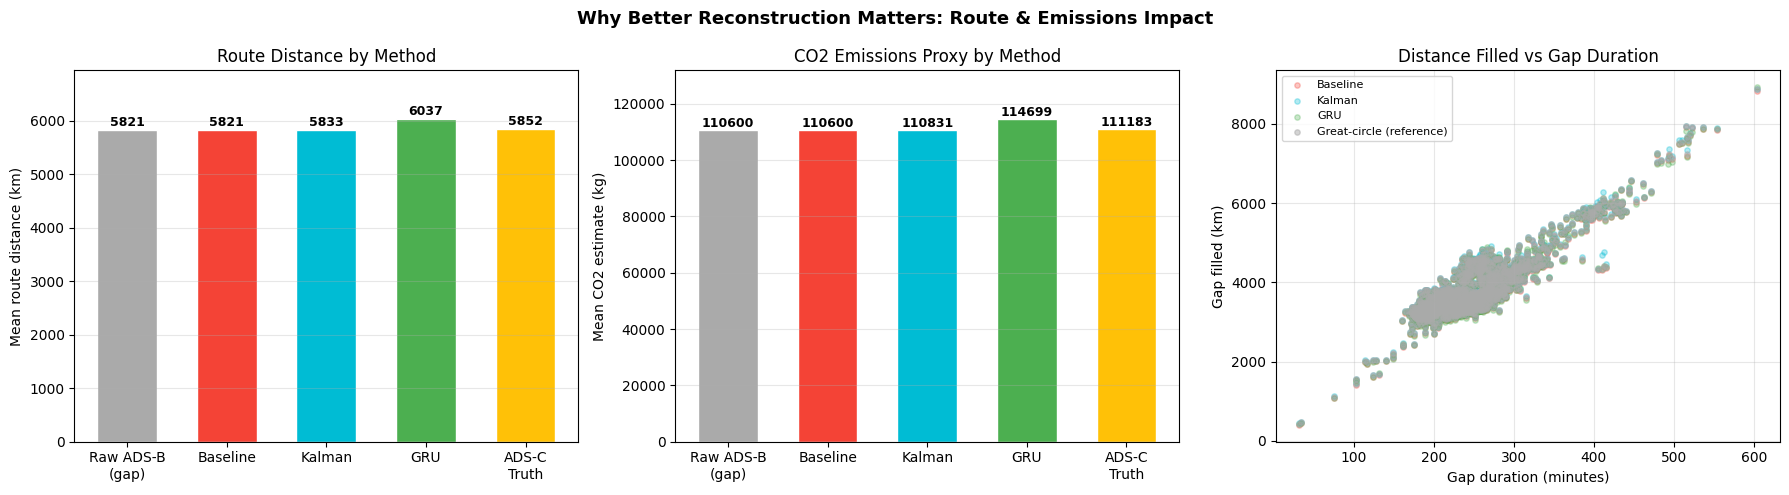

Saved -> C:\Users\marko\Desktop\AeroML3(og)\AeroML3\outputs\analytics_comparison.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Plot 1: Route distance comparison ----------------------------------------
ax = axes[0]
methods_dist = [
    ("Raw ADS-B\n(gap)", "raw_adsb_dist_km",  "#AAAAAA"),
    ("Baseline",          "baseline_dist_km",   "#F44336"),
    ("Kalman",            "kalman_dist_km",      "#00BCD4"),
    ("GRU",               "gru_dist_km",         "#4CAF50"),
]
if analytics_df["adsc_true_dist_km"].notna().sum() > 0:
    methods_dist.append(("ADS-C\nTruth", "adsc_true_dist_km", "#FFC107"))

labels = [m[0] for m in methods_dist]
means  = [analytics_df[m[1]].dropna().mean() for m in methods_dist]
colors = [m[2] for m in methods_dist]

bars = ax.bar(labels, means, color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Mean route distance (km)")
ax.set_title("Route Distance by Method")
ax.set_ylim(0, max(means) * 1.15)
ax.grid(axis="y", alpha=0.3)

# -- Plot 2: CO2 emissions proxy -----------------------------------------------
ax = axes[1]
methods_co2 = [
    ("Raw ADS-B\n(gap)", "raw_co2_kg",      "#AAAAAA"),
    ("Baseline",          "baseline_co2_kg",  "#F44336"),
    ("Kalman",            "kalman_co2_kg",     "#00BCD4"),
    ("GRU",               "gru_co2_kg",        "#4CAF50"),
]
if analytics_df["adsc_co2_kg"].notna().sum() > 0:
    methods_co2.append(("ADS-C\nTruth", "adsc_co2_kg", "#FFC107"))

labels2 = [m[0] for m in methods_co2]
means2  = [analytics_df[m[1]].dropna().mean() for m in methods_co2]
colors2 = [m[2] for m in methods_co2]

bars2 = ax.bar(labels2, means2, color=colors2, edgecolor="white", width=0.6)
for bar, val in zip(bars2, means2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Mean CO2 estimate (kg)")
ax.set_title("CO2 Emissions Proxy by Method")
ax.set_ylim(0, max(means2) * 1.15)
ax.grid(axis="y", alpha=0.3)

# -- Plot 3: Gap filled vs gap duration ----------------------------------------
ax = axes[2]
ax.scatter(analytics_df["gap_minutes"], analytics_df["baseline_gap_km"],
           alpha=0.3, s=15, color="#F44336", label="Baseline")
ax.scatter(analytics_df["gap_minutes"], analytics_df["kalman_gap_km"],
           alpha=0.3, s=15, color="#00BCD4", label="Kalman")
if analytics_df["gru_gap_km"].notna().sum() > 0:
    ax.scatter(analytics_df["gap_minutes"], analytics_df["gru_gap_km"],
               alpha=0.3, s=15, color="#4CAF50", label="GRU")
ax.scatter(analytics_df["gap_minutes"], analytics_df["gc_gap_km"],
           alpha=0.5, s=15, color="#AAAAAA", label="Great-circle (reference)")
ax.set_xlabel("Gap duration (minutes)")
ax.set_ylabel("Gap filled (km)")
ax.set_title("Distance Filled vs Gap Duration")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle("Why Better Reconstruction Matters: Route & Emissions Impact",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out_fig = OUT_DIR / "analytics_comparison.png"
plt.savefig(out_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_fig}")

## Cell 6 - Key insight: underestimation problem

In [ ]:
# -- Underestimation analysis -------------------------------------------------
gap_col    = analytics_df["gc_gap_km"]
raw_col    = analytics_df["raw_adsb_dist_km"]
base_col   = analytics_df["baseline_dist_km"]
kalman_col = analytics_df["kalman_dist_km"]
gru_col    = analytics_df["gru_dist_km"]
adsc_col   = analytics_df["adsc_true_dist_km"]

raw_mean    = raw_col.mean()
base_mean   = base_col.mean()
kalman_mean = kalman_col.mean()
gru_mean    = gru_col.dropna().mean()

print("KEY FINDING: The Raw ADS-B Underestimation Problem")
print("=" * 58)
print(f"\nRaw ADS-B has no coverage over the ocean -- the gap is simply missing.")
print(f"Reconstruction methods fill that gap, revealing the true route distance.")
print(f"\nAverage gap duration       : {analytics_df['gap_minutes'].mean():.0f} min")
print(f"Average gap distance       : {gap_col.mean():.0f} km (great-circle)")
print()
print(f"{'Method':<22}  {'Mean dist (km)':>14}  {'vs Raw ADS-B':>13}")
print("-" * 54)
print(f"  {'Raw ADS-B (no gap)':<20}  {raw_mean:>14.0f}  {'--':>13}")
print(f"  {'Baseline':<20}  {base_mean:>14.0f}  {base_mean - raw_mean:>+13.0f} km")
print(f"  {'Kalman':<20}  {kalman_mean:>14.0f}  {kalman_mean - raw_mean:>+13.0f} km")
print(f"  {'GRU v2':<20}  {gru_mean:>14.0f}  {gru_mean - raw_mean:>+13.0f} km")
if adsc_col.notna().sum() > 0:
    adsc_mean = adsc_col.dropna().mean()
    print(f"  {'ADS-C truth':<20}  {adsc_mean:>14.0f}  {adsc_mean - raw_mean:>+13.0f} km")

underest_km  = base_mean - raw_mean
underest_pct = (underest_km / base_mean) * 100

print(f"\nMissed distance per flight : ~{underest_km:.0f} km ({underest_pct:.1f}% of full route)")
print(f"CO2 underestimate/flight   : {underest_km * CO2_KG_PER_KM:.0f} kg")
print(f"CO2 underestimate/year     : {underest_km * CO2_KG_PER_KM * 365:.0f} kg (one daily flight)")

print("\n-- Why this matters --")
print(f"  100 long-haul aircraft each flying daily:")
print(f"  Unaccounted CO2 = {underest_km * CO2_KG_PER_KM * 365 * 100 / 1e6:.1f} million kg/year")
print(f"  Better reconstruction closes this tracking gap.")

print("\n-- Deviation from expected (great-circle) path --")
print(f"  Baseline: {analytics_df['baseline_dev_km'].mean():.1f} km (straight arc -- zero deviation by design)")
if analytics_df['kalman_dev_km'].notna().sum() > 0:
    print(f"  Kalman  : {analytics_df['kalman_dev_km'].mean():.1f} km (small deviation from velocity drift)")
if analytics_df['gru_dev_km'].notna().sum() > 0:
    print(f"  GRU v2  : {analytics_df['gru_dev_km'].mean():.1f} km (learned deviation from training data)")
print(f"\n  Real flights deviate from great-circle to follow jet streams.")
print(f"  A better reconstruction captures this, giving more realistic analytics.")
